# **Australian Solar Generation Forecasting**

## **Step 1: Environment Setup & Time Series Fundamentals**

**Research/Learn:**

*   **Time series forecasting** predicts future values using historical data, crucial for trend and seasonal analysis. **Univariate forecasting** uses a **single** variable's past to predict its future, while **multivariate** uses **multiple** interdependent variables. **Probabilistic forecasts** provide a **probability distribution** of potential future values, capturing uncertainty better than deterministic point forecasts.

*   **NASA POWER** (Source API docs: https://power.larc.nasa.gov/api/pages/#/) provides analysis-ready solar and meteorological time series for
energy applications. The Temporal API family includes **Hourly**, **Daily**, **Monthly**, and **Climatology** services. Of these, Hourly is the most useful for our energy optimization engine because it provides hour-by-hour values, while Daily is a strong fallback or simpler first integration. NASA’s Temporal overview also shows that Hourly supports Point only, while Daily, Monthly, and Climatology support both Point and Regional. For our system, NASA POWER is useful because it adds a real environmental layer
for:
    * solar generation modeling
    * battery charge/discharge simulation
    * EV charging optimization
    * TOU-aware cost simulation
    * stronger scenario confidence

*   **Australian postcode datasets** are geographical collections that link postcodes across Australia to their corresponding physical locations. These datasets are essential for spatial analysis and localized data retrieval in technical projects.

    * **Core Attributes:** Each record typically includes the 4-digit Australian postcode, suburb/locality names, state, and precise geographic coordinates (Latitude and Longitude).

    * **Data Formats:** These datasets are commonly available in open-standard formats such as CSV for tabular processing or GeoJSON for mapping and spatial queries.

In [ ]:
# install libraries ( transformers , datasets , gluonts , chronos , pandas , requests )
!pip install transformers datasets gluonts chronos pandas requests

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.7 MB/s eta 0:00:00
  Created wheel for chronos: filename=chronos-0.3-py3-none-any.whl size=7373 sha256=007221a0b2e016843461f581302bba4b192f7e3ac158283bb8636abac11a2c6b
  Stored in directory: /root/.cache/pip/wheels/b5/9c/d5/1dbbab8b167406e7058cf3c96fa031b98ef022b893a66c634a
Successfully built chronos


In [ ]:
# HF account
from huggingface_hub import HfApi

api = HfApi()

user_info = api.whoami()

user_info

{'type': 'user',
 'id': '68810e5b766eae4f6f2ac465',
 'name': 'codenhenhe',
 'fullname': 'Nguyễn Nhựt Linh',
 'email': 'linhnguyennhut07103@gmail.com',
 'emailVerified': True,
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1780272000,
 'isPro': False,
 'avatarUrl': '/avatars/029b932f62a41833fc86c6dac1282cda.svg',
 'orgs': [],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'solar-generation-forecasting',
   'role': 'write',
   'createdAt': '2026-05-06T03:31:37.355Z'}}}

In [ ]:
# HF token
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

print(type(HF_TOKEN))

<class 'str'>


In [ ]:
!curl --location 'https://power.larc.nasa.gov/api/temporal/daily/point?parameters=ALLSKY_SFC_SW_DWN%2CT2M&community=RE&longitude=114.852437&latitude=-27.832196&start=20160101&end=20260430&format=JSON'

{"type":"Feature","geometry":{"type":"Point","coordinates":[114.852,-27.832,246.59]},"properties":{"parameter":{"ALLSKY_SFC_SW_DWN":{"20160101":8.9544,"20160102":8.5466,"20160103":8.2236,"20160104":5.635,"20160105":5.394,"20160106":8.2738,"20160107":7.3625,"20160108":8.5915,"20160109":8.6011,"20160110":7.6752,"20160111":8.2174,"20160112":7.686,"20160113":7.6999,"20160114":7.2845,"20160115":8.028,"20160116":6.6989,"20160117":6.4668,"20160118":5.3532,"20160119":6.3754,"20160120":7.7167,"20160121":5.8301,"20160122":8.1257,"20160123":8.3906,"20160124":6.9996,"20160125":5.6066,"20160126":8.3916,"20160127":7.4777,"20160128":5.5296,"20160129":5.1797,"20160130":7.0231,"20160131":5.5678,"20160201":8.875,"20160202":8.9438,"20160203":8.9566,"20160204":8.9004,"20160205":8.8238,"20160206":8.7672,"20160207":8.7295,"20160208":8.7026,"20160209":8.5848,"20160210":8.5361,"20160211":8.4485,"20160212":8.3573,"20160213":8.2891,"20160214":8.3338,"20160215":8.0503,"20160216":7.4318,"20160217":7.6598,"2016021

In [ ]:
import requests
import pandas as pd

def get_coordinates(postcode):
    lookup_table = {
        "2000": {"lat": -33.86, "long": 151.21},
    }
    return lookup_table.get(postcode, None)

def fetch_nasa_data(lat, long, start_date="20200101", end_date="20200131"):
    url = f"https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=ALLSKY_SFC_SW_DWN%2CT2M&community=RE&longitude={long}&latitude={lat}&start={start_date}&end={end_date}&format=JSON"

    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        df = pd.DataFrame(data['properties']['parameter'])
        return df
    else:
        return f"Error: {response.status_code}"

In [ ]:
postcode_test = "2000"
coords = get_coordinates(postcode_test)

if coords:
    print(f"Fetching data for Postcode {postcode_test} (Lat: {coords['lat']}, Lon: {coords['long']})...")
    result_df = fetch_nasa_data(coords['lat'], coords['long'])
    print(result_df)
else:
    print("Postcode không tồn tại trong hệ thống test.")

Fetching data for Postcode 2000 (Lat: -33.86, Lon: 151.21)...
            ALLSKY_SFC_SW_DWN    T2M
2020010100                0.0  20.19
2020010101                0.0  19.68
2020010102                0.0  19.38
2020010103                0.0  19.20
2020010104                0.0  19.19
...                       ...    ...
2020013119                0.0  25.12
2020013120                0.0  24.83
2020013121                0.0  24.65
2020013122                0.0  24.52
2020013123                0.0  24.34

[744 rows x 2 columns]


## **Step 2: Postcode to Lat/Long Mapping**

Link dataset: https://github.com/matthewproctor/australianpostcodes/blob/master/australian_postcodes.csv

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_origin = pd.read_csv("/content/drive/MyDrive/TT/data/postcodes/australian_postcodes.csv")

In [ ]:
df_origin[df_origin['postcode'] == 852]

,id,postcode,locality,state,long,lat,dc,type,status,sa3,...,altitude,chargezone,phn_code,phn_name,lgaregion,lgacode,electorate,electoraterating,sed_code,sed_name
220,20071,852,ARNOLD,NT,130.841866,-16.452589,Katherine,Delivery Area,Updated 3-Dec-2022,70205.0,...,99.822197,NT1,PHN701,Northern Territory,NaN,NaN,Lingiari,Rural,70017.0,Katherine
221,20072,852,BAINES,NT,130.841866,-16.452589,Katherine,Delivery Area,Updated 3-Dec-2022,70205.0,...,99.822197,NT1,PHN701,Northern Territory,NaN,NaN,Lingiari,Rural,70017.0,Katherine
222,20073,852,BARUNGA,NT,130.841866,-16.452589,Katherine,Delivery Area,Updated 3-Dec-2022,70205.0,...,99.822197,NT1,PHN701,Northern Territory,NaN,NaN,Lingiari,Rural,70017.0,Katherine
223,360,852,BESWICK,NT,130.841866,-16.452589,Katherine,Delivery Area,Updated 6-Sep-2025,70205.0,...,99.822197,NT1,PHN701,Northern Territory,NaN,NaN,Lingiari,Rural,70017.0,Katherine
224,20074,852,BESWICK CREEK,NT,130.841866,-16.452589,Katherine,Delivery Area,Updated 3-Dec-2022,70205.0,...,99.822197,NT1,PHN701,Northern Territory,NaN,NaN,Lingiari,Rural,70017.0,Katherine
225,20075,852,BINJARI,NT,130.841866,-16.452589,Katherine,Delivery Area,Updated 3-Dec-2022,70205.0,...,99.822197,NT1,PHN701,Northern Territory,NaN,NaN,Lingiari,Rural,70017.0,Katherine
226,20076,852,BIRDUM,NT,130.841866,-16.452589,Katherine,Delivery Area,Updated 3-Dec-2022,70205.0,...,99.822197,NT1,PHN701,Northern Territory,NaN,NaN,Lingiari,Rural,70017.0,Katherine
227,20077,852,BRADSHAW,NT,130.841866,-16.452589,Katherine,Delivery Area,Updated 3-Dec-2022,70205.0,...,99.822197,NT1,PHN701,Northern Territory,NaN,NaN,Lingiari,Rural,70017.0,Katherine
228,20078,852,BUCHANAN,NT,130.841866,-16.452589,Katherine,Delivery Area,Updated 3-Dec-2022,70205.0,...,99.822197,NT1,PHN701,Northern Territory,NaN,NaN,Lingiari,Rural,70017.0,Katherine
229,20079,852,BULMAN WEEMOL,NT,130.841866,-16.452589,Katherine,Delivery Area,Updated 3-Dec-2022,70205.0,...,99.822197,NT1,PHN701,Northern Territory,NaN,NaN,Lingiari,Rural,70017.0,Katherine


In [ ]:
postcode_counts = (
    df_origin["postcode"]
    .value_counts()
    .reset_index()
)

postcode_counts.columns = ["postcode", "count"]

postcode_counts = postcode_counts.sort_values(
    "count",
    ascending=False
)

print(postcode_counts.head(20))

    postcode  count
0        822    111
1        872    110
2       4702    106
3       2795    103
4       2460     97
5       4871     92
6       4570     89
7       4352     79
8       2850     79
9       2480     75
10      2540     70
11      4740     69
12      2330     65
14      2469     64
13      4306     64
16      2650     62
15      3352     62
18      6532     59
17       852     59
19      2484     58


In [ ]:
df_origin[df_origin['postcode'] == 822]

,id,postcode,locality,state,long,lat,dc,type,status,sa3,...,altitude,chargezone,phn_code,phn_name,lgaregion,lgacode,electorate,electoraterating,sed_code,sed_name
60,282,822,ACACIA HILLS,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 6-Sep-2025,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
61,19980,822,ANGURUGU,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
62,19981,822,ANINDILYAKWA,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
63,19982,822,ANNIE RIVER,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
64,19983,822,BATHURST ISLAND,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,20053,822,WICKHAM,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
167,320,822,WINNELLIE,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 6-Sep-2025,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
168,20054,822,WISHART,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
169,321,822,WOOLANING,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 6-Sep-2025,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett


In [ ]:
df_main = df_origin.groupby('postcode')[['lat', 'long']].mean().reset_index()
df_main

,postcode,lat,long
0,200,-35.277700,149.118950
1,800,-12.458684,130.836680
2,801,-12.458684,130.836680
3,803,-12.433991,130.745908
4,804,-12.428017,130.873315
...,...,...,...
3170,9013,-27.603479,152.823141
3171,9015,-27.603479,152.823141
3172,9464,-27.397055,153.074982
3173,9726,-28.008783,153.412197


In [ ]:
def lat_long_mapping(postcode):
  res = df_main.loc[df_main['postcode'] == postcode, ['lat', 'long']]
  if not res.empty:
    return res['lat'].mean(), res['long'].mean()
  return None, None

In [ ]:
lat, long = lat_long_mapping(3000)

print(f"lat: {lat}")
print(f"long: {long}")

lat: -37.81443733
long: 144.9825846


## **Step 3: NASA POWER API Integration**

This step integrates postcode-based geographic data with the NASA POWER API to collect historical daily weather data for solar generation forecasting.

### Selecting Solar Reference Points

KMeans clustering is applied to the cleaned Australian postcode coordinates. The number of clusters is set to `500`, which means that 500 representative solar reference locations are created.

```python
n_optimal = 500

kmeans = KMeans(n_clusters=n_optimal, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(coords)
```

Since KMeans cluster centers may not correspond to real postcode locations, the nearest actual postcode point to each cluster center is selected as the reference point.

```python
distances = np.linalg.norm(
    cluster_points[['lat', 'long']].values - center,
    axis=1
)

closest_point_idx = distances.argmin()
```

Each selected point is assigned a unique `solar_ref_id`, such as `AUS_SOLAR_REF_000`, and saved as a solar reference point.

```python
df_ref_points.to_csv('/content/volta_solar_reference_points.csv', index=False)
```

### Mapping Postcodes to Reference Points

Each postcode is mapped to its assigned cluster and corresponding `solar_ref_id`.

```python
df_mapping['solar_ref_id'] = df_mapping['cluster'].apply(
    lambda x: f'AUS_SOLAR_REF_{x:03d}'
)
```

The approximate distance between each postcode and its assigned reference point is also calculated. The latitude-longitude difference is converted into kilometers using an approximate factor of `111 km` per degree.

```python
df_mapping['distance_km'] = np.sqrt(
    (df_mapping['lat'] - df_mapping['ref_lat'])**2 +
    (df_mapping['long'] - df_mapping['ref_long'])**2
) * 111
```

The postcode-to-reference mapping is saved as:

```text
postcode_to_ref_mapping.csv
```

### Downloading NASA POWER Daily Weather Data

The function `fetch_nasa_daily_volta()` downloads daily weather data from the NASA POWER API for each solar reference point.

The selected weather variables are:

```text
ALLSKY_SFC_SW_DWN, T2M, WS2M, RH2M
```

These variables represent solar radiation, temperature, wind speed, and relative humidity.

```python
params = "ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M"
```

For each reference point, the function builds an API request using its latitude and longitude, downloads the JSON response, and saves it locally.

```python
url = (
    f"https://power.larc.nasa.gov/api/temporal/daily/point?"
    f"parameters={params}&community=RE&longitude={lon}&latitude={lat}"
    f"&start={start_date}&end={end_date}&format=JSON"
)
```

Existing JSON files are skipped to avoid repeated downloads. A short delay is also added between requests to reduce the risk of reaching API limits.

### Building the Final Postcode Lookup Table

The function `build_postcode_lookup()` creates the final lookup table used by the forecasting pipeline. If a postcode appears multiple times, the best row is selected using the following priority rules:

1. Choose the row with the smallest `distance_km`.
2. If there is a tie, choose the station with the largest `station_size`.
3. If there is still a tie, choose the smallest `solar_ref_id`.

The final lookup table keeps only the columns required by the pipeline:

```text
postcode
solar_ref_id
cluster
ref_lat
ref_long
distance_km
station_size
```

The final lookup file is saved as:

```text
postcode_to_solar_ref_lookup.csv
```

This lookup file allows the system to resolve a user-provided postcode into its nearest representative solar reference point for weather data retrieval and solar generation forecasting.

Đang tính toán Elbow Method, vui lòng đợi...


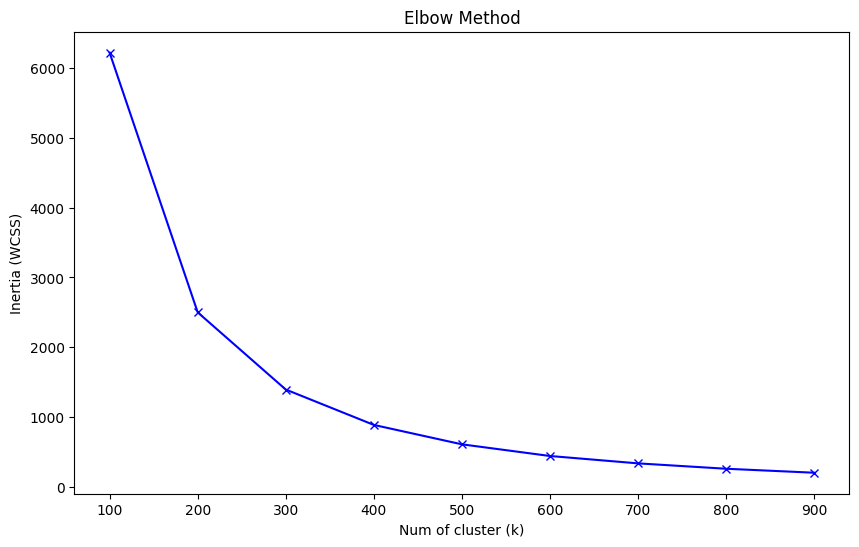

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/TT/data/postcodes/australian_postcodes.csv')

df_clean = df.dropna(subset=['lat', 'long'])
df_clean = df_clean[df_clean['type'] != 'PO Box'] # Tập trung vào khu vực dân cư
coords = df_clean[['lat', 'long']].values

print("Đang tính toán Elbow Method, vui lòng đợi...")
inertia = []
k_range = range(100, 901, 100) # Thử nghiệm từ 100 đến 900 trạm

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords)
    inertia.append(km.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bx-')
plt.xlabel('Num of cluster (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.show()

In [ ]:
n_optimal = 500
print(f"Đang tiến hành phân cụm với k = {n_optimal}...")

kmeans = KMeans(n_clusters=n_optimal, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(coords)

# Tìm "Medoids" thực tế
reference_points = []
for i in range(n_optimal):
    cluster_points = df_clean[df_clean['cluster'] == i]
    center = kmeans.cluster_centers_[i]

    # Tính khoảng cách Euclidean
    distances = np.linalg.norm(cluster_points[['lat', 'long']].values - center, axis=1)
    closest_point_idx = distances.argmin()

    ref_point = cluster_points.iloc[closest_point_idx].copy()
    reference_points.append({
        'solar_ref_id': f'AUS_SOLAR_REF_{i:03d}',
        'lat': ref_point['lat'],
        'long': ref_point['long'],
        'state': ref_point['state'],
        'postcode': ref_point['postcode']
    })

df_ref_points = pd.DataFrame(reference_points)
df_ref_points.to_csv('/content/volta_solar_reference_points.csv', index=False)

# print(f"Hoàn tất! Đã lưu {len(df_ref_points)} trạm tham chiếu.")

Đang tiến hành phân cụm với k = 500...


In [ ]:
df_mapping = df_clean[['postcode', 'lat', 'long', 'cluster']].copy()

df_mapping['solar_ref_id'] = df_mapping['cluster'].apply(lambda x: f'AUS_SOLAR_REF_{x:03d}')

# Lấy tọa độ của các trạm để so sánh
ref_coords = df_ref_points[['lat', 'long']].values
df_mapping['ref_lat'] = df_mapping['cluster'].apply(lambda x: ref_coords[x][0])
df_mapping['ref_long'] = df_mapping['cluster'].apply(lambda x: ref_coords[x][1])

df_mapping['distance_km'] = np.sqrt(
    (df_mapping['lat'] - df_mapping['ref_lat'])**2 +
    (df_mapping['long'] - df_mapping['ref_long'])**2
) * 111

df_mapping.to_csv('/content/postcode_to_ref_mapping.csv', index=False)
print("Đã tạo xong file Mapping postcode!")

Đã tạo xong file Mapping postcode!


In [ ]:
import requests
import json
import os
import time
import pandas as pd

def fetch_nasa_daily_volta(ref_points_path, start_date = "20160101", end_date = "20251231", save_dir="/content/nasa_data_daily"):
    # 1. Tạo thư mục lưu trữ
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"Đã tạo thư mục: {save_dir}")

    df_refs = pd.read_csv(ref_points_path)

    # Bức xạ, Nhiệt độ, Tốc độ gió, Độ ẩm
    params = "ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M"

    print(f"Bắt đầu tải dữ liệu cho {len(df_refs)} trạm...")

    for i, row in df_refs.iterrows():
        ref_id = row['solar_ref_id']
        lat = row['lat']
        lon = row['long']
        file_path = os.path.join(save_dir, f"{ref_id}.json")

        if os.path.exists(file_path):
            continue

        url = (
            f"https://power.larc.nasa.gov/api/temporal/daily/point?"
            f"parameters={params}&community=RE&longitude={lon}&latitude={lat}"
            f"&start={start_date}&end={end_date}&format=JSON"
        )

        try:
            response = requests.get(url, timeout=60)
            if response.status_code == 200:
                with open(file_path, 'w', encoding='utf-8') as f:
                    json.dump(response.json(), f, ensure_ascii=False)

                if (i + 1) % 10 == 0:
                    print(f"--- Đã tải xong {i + 1}/{len(df_refs)} trạm ---")

                # Nghỉ ngắn để không bị NASA chặn
                time.sleep(1.1)

            elif response.status_code == 429:
                print(f"Chạm giới hạn API tại {ref_id}, nghỉ 30s...")
                time.sleep(30)
            else:
                print(f"Lỗi {response.status_code} tại trạm {ref_id}")

        except Exception as e:
            print(f"Lỗi kết nối tại trạm {ref_id}: {e}")

    print(f"Hoàn tất! Tất cả file JSON nằm tại: {save_dir}")

# ref_points_path = "/content/drive/MyDrive/TT/data/volta_solar_reference_points.csv"
# json_dir = "/content/drive/MyDrive/TT/data/raw/daily/"

# fetch_nasa_daily_volta(ref_points_path, save_dir=json_dir)

Bắt đầu tải dữ liệu cho 500 trạm...
--- Đã tải xong 10/500 trạm ---
--- Đã tải xong 20/500 trạm ---
--- Đã tải xong 30/500 trạm ---
--- Đã tải xong 40/500 trạm ---
--- Đã tải xong 50/500 trạm ---
--- Đã tải xong 60/500 trạm ---
--- Đã tải xong 70/500 trạm ---
--- Đã tải xong 80/500 trạm ---
--- Đã tải xong 90/500 trạm ---
--- Đã tải xong 100/500 trạm ---
--- Đã tải xong 110/500 trạm ---
--- Đã tải xong 120/500 trạm ---
--- Đã tải xong 130/500 trạm ---
--- Đã tải xong 140/500 trạm ---
--- Đã tải xong 150/500 trạm ---
--- Đã tải xong 160/500 trạm ---
--- Đã tải xong 170/500 trạm ---
--- Đã tải xong 180/500 trạm ---
--- Đã tải xong 190/500 trạm ---
--- Đã tải xong 200/500 trạm ---
--- Đã tải xong 210/500 trạm ---
--- Đã tải xong 220/500 trạm ---
--- Đã tải xong 230/500 trạm ---
--- Đã tải xong 240/500 trạm ---
--- Đã tải xong 250/500 trạm ---
--- Đã tải xong 260/500 trạm ---
--- Đã tải xong 270/500 trạm ---
--- Đã tải xong 280/500 trạm ---
--- Đã tải xong 290/500 trạm ---
--- Đã tải xong 

In [ ]:
import pandas as pd

ref_points_path = "/content/drive/MyDrive/TT/data/postcode_to_ref_mapping.csv"
# ref_points_path = "/content/drive/MyDrive/TT/data/volta_solar_reference_points.csv"

ref_df = pd.read_csv(ref_points_path)

# ref_df[ref_df['postcode'] == 852]

ref_df

,postcode,lat,long,cluster,solar_ref_id,ref_lat,ref_long,distance_km
0,200,-35.277700,149.119000,32,AUS_SOLAR_REF_032,-35.275863,149.113796,0.612577
1,200,-35.277700,149.118900,32,AUS_SOLAR_REF_032,-35.275863,149.113796,0.602121
2,800,-12.458684,130.836680,364,AUS_SOLAR_REF_364,-12.428017,130.873315,5.303185
3,800,-12.458684,130.836680,364,AUS_SOLAR_REF_364,-12.428017,130.873315,5.303185
4,801,-12.458684,130.836680,364,AUS_SOLAR_REF_364,-12.428017,130.873315,5.303185
...,...,...,...,...,...,...,...,...
18554,9013,-27.603479,152.823141,368,AUS_SOLAR_REF_368,-27.603479,152.823141,0.000000
18555,9015,-27.603479,152.823141,368,AUS_SOLAR_REF_368,-27.603479,152.823141,0.000000
18556,9464,-27.397055,153.074982,472,AUS_SOLAR_REF_472,-27.373947,153.084784,2.786208
18557,9726,-28.008783,153.412197,187,AUS_SOLAR_REF_187,-27.967005,153.365576,6.948741


In [ ]:
import pandas as pd

def build_postcode_lookup(
    mapping_df: pd.DataFrame,
    output_path: str = None
) -> pd.DataFrame:
    """
    Build final postcode lookup table.

    Rule:
    1. Choose smallest distance_km.
    2. If tie, choose station with largest number of assigned rows.
    3. If still tie, choose smallest solar_ref_id for deterministic result.

    Expected columns:
    - postcode
    - lat
    - long
    - cluster
    - solar_ref_id
    - ref_lat
    - ref_long
    - distance_km
    """

    df = mapping_df.copy()

    required_cols = [
        "postcode", "lat", "long", "cluster",
        "solar_ref_id", "ref_lat", "ref_long", "distance_km"
    ]

    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    df["postcode"] = df["postcode"].astype(int)
    df["cluster"] = df["cluster"].astype(int)
    df["solar_ref_id"] = df["solar_ref_id"].astype(str)
    df["distance_km"] = df["distance_km"].astype(float)

    # Bỏ dòng trùng hoàn toàn nếu có
    df = df.drop_duplicates()

    # Tính số lượng dòng/điểm thuộc mỗi trạm
    station_size = (
        df.groupby("solar_ref_id")
        .size()
        .rename("station_size")
        .reset_index()
    )

    df = df.merge(station_size, on="solar_ref_id", how="left")

    # Sắp xếp theo rule:
    # 1. postcode tăng dần
    # 2. distance_km nhỏ nhất
    # 3. station_size lớn nhất
    # 4. solar_ref_id nhỏ nhất
    df_sorted = df.sort_values(
        by=["postcode", "distance_km", "station_size", "solar_ref_id"],
        ascending=[True, True, False, True]
    )

    # Mỗi postcode chỉ giữ 1 dòng tốt nhất
    lookup_df = (
        df_sorted
        .drop_duplicates(subset=["postcode"], keep="first")
        .reset_index(drop=True)
    )

    # Chỉ giữ các cột cần dùng cho pipeline
    lookup_df = lookup_df[
        [
            "postcode",
            "solar_ref_id",
            "cluster",
            "ref_lat",
            "ref_long",
            "distance_km",
            "station_size"
        ]
    ]

    # Lưu file nếu có truyền output_path
    if output_path is not None:
        lookup_df.to_csv(output_path, index=False)
        print(f"Saved postcode lookup to: {output_path}")

    return lookup_df

In [ ]:
postcode_lookup_df = build_postcode_lookup(
    ref_df,
    output_path="/content/drive/MyDrive/TT/data/postcode_to_solar_ref_lookup.csv"
)

postcode_lookup_df.head()

Saved postcode lookup to: /content/drive/MyDrive/TT/data/postcode_to_solar_ref_lookup.csv


,postcode,solar_ref_id,cluster,ref_lat,ref_long,distance_km,station_size
0,200,AUS_SOLAR_REF_032,32,-35.275863,149.113796,0.602121,60
1,800,AUS_SOLAR_REF_364,364,-12.428017,130.873315,5.303185,40
2,801,AUS_SOLAR_REF_364,364,-12.428017,130.873315,5.303185,40
3,803,AUS_SOLAR_REF_364,364,-12.428017,130.873315,14.157683,40
4,804,AUS_SOLAR_REF_364,364,-12.428017,130.873315,0.000000,40


In [ ]:
postcode_lookup_df

,postcode,solar_ref_id,cluster,ref_lat,ref_long,distance_km,station_size
0,200,AUS_SOLAR_REF_032,32,-35.275863,149.113796,0.602121,60
1,800,AUS_SOLAR_REF_364,364,-12.428017,130.873315,5.303185,40
2,801,AUS_SOLAR_REF_364,364,-12.428017,130.873315,5.303185,40
3,803,AUS_SOLAR_REF_364,364,-12.428017,130.873315,14.157683,40
4,804,AUS_SOLAR_REF_364,364,-12.428017,130.873315,0.000000,40
...,...,...,...,...,...,...,...
3170,9013,AUS_SOLAR_REF_368,368,-27.603479,152.823141,0.000000,23
3171,9015,AUS_SOLAR_REF_368,368,-27.603479,152.823141,0.000000,23
3172,9464,AUS_SOLAR_REF_472,472,-27.373947,153.084784,2.786208,28
3173,9726,AUS_SOLAR_REF_187,187,-27.967005,153.365576,6.948741,22


In [ ]:
postcode_lookup_df["postcode"].duplicated().sum()

np.int64(0)

In [ ]:
print("Số postcode gốc:", ref_df["postcode"].nunique())
print("Số postcode lookup:", postcode_lookup_df["postcode"].nunique())
print("Số dòng lookup:", len(postcode_lookup_df))

Số postcode gốc: 3175
Số postcode lookup: 3175
Số dòng lookup: 3175


In [ ]:
json_dir = "/content/drive/MyDrive/TT/data/raw/daily/"
ref_points_path = "/content/drive/MyDrive/TT/data/volta_solar_reference_points.csv"

import json
import os
import glob
import pandas as pd

def merge_nasa_json_to_csv(json_dir="/content/nasa_data_daily", output_file="/content/volta_master_daily.csv"):
    all_stations_data = []

    # Lấy danh sách tất cả các file .json trong thư mục
    json_files = glob.glob(os.path.join(json_dir, "*.json"))

    if not json_files:
        print("Không tìm thấy file JSON nào trong thư mục!")
        return

    print(f"Đang xử lý {len(json_files)} file JSON...")

    target_end_date = pd.to_datetime("2025-12-31")

    for file_path in json_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            ref_id = os.path.basename(file_path).replace('.json', '')
            lat = data['geometry']['coordinates'][1]
            lon = data['geometry']['coordinates'][0]

            params_dict = data['properties']['parameter']

            df_station = pd.DataFrame(params_dict)

            df_station['date'] = pd.to_datetime(df_station.index, format='%Y%m%d')

            df_station = df_station[df_station['date'] <= target_end_date]

            # Thêm thông tin định danh trạm
            df_station['solar_ref_id'] = ref_id
            df_station['lat'] = lat
            df_station['long'] = lon

            all_stations_data.append(df_station)

        except Exception as e:
            print(f"Lỗi khi xử lý file {file_path}: {e}")

    # Nối tất cả các trạm thành một bảng tổng duy nhất
    if all_stations_data:
        master_df = pd.concat(all_stations_data, ignore_index=True)

        # Sắp xếp lại các cột cho dễ nhìn
        cols = ['solar_ref_id', 'date', 'lat', 'long', 'ALLSKY_SFC_SW_DWN', 'T2M', 'WS2M', 'RH2M']
        master_df = master_df[cols]

        # Sắp xếp dữ liệu theo trạm và thời gian
        master_df = master_df.sort_values(['solar_ref_id', 'date'])

        # Lưu thành file CSV
        master_df.to_csv(output_file, index=False)
        print(f"Hoàn tất! Đã lưu file tổng.")
        return master_df
    else:
        print("Không có dữ liệu để gộp.")

# Gộp dữ liệu
master_df = merge_nasa_json_to_csv(json_dir=json_dir, output_file="/content/drive/MyDrive/TT/data/main/daily/raw.csv")

Đang xử lý 500 file JSON...
Hoàn tất! Đã lưu file tổng.


In [ ]:
daily_raw = pd.read_csv("/content/drive/MyDrive/TT/data/main/daily/raw.csv")
# Chuyển đổi cột date sang datetime
daily_raw['date'] = pd.to_datetime(daily_raw['date'])

print(daily_raw['date'].dtype)
daily_raw

datetime64[ns]


,solar_ref_id,date,lat,long,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M
0,AUS_SOLAR_REF_000,2016-01-01,-27.832,114.852,8.9544,31.15,4.20,40.78
1,AUS_SOLAR_REF_000,2016-01-02,-27.832,114.852,8.5466,26.56,4.61,53.99
2,AUS_SOLAR_REF_000,2016-01-03,-27.832,114.852,8.2236,26.15,2.78,55.57
3,AUS_SOLAR_REF_000,2016-01-04,-27.832,114.852,5.6350,25.23,3.16,58.72
4,AUS_SOLAR_REF_000,2016-01-05,-27.832,114.852,5.3940,24.70,3.66,59.91
...,...,...,...,...,...,...,...,...
1826495,AUS_SOLAR_REF_499,2025-12-27,-33.865,147.461,9.6631,19.30,2.33,41.20
1826496,AUS_SOLAR_REF_499,2025-12-28,-33.865,147.461,8.7079,21.64,3.20,37.60
1826497,AUS_SOLAR_REF_499,2025-12-29,-33.865,147.461,9.6110,24.35,1.99,34.56
1826498,AUS_SOLAR_REF_499,2025-12-30,-33.865,147.461,8.8459,27.43,1.90,27.50


In [ ]:
# Kiểm tra số lượng dòng của từng trạm
status_check = daily_raw.groupby('solar_ref_id').size()

print("Số dòng trung bình mỗi trạm:", status_check.mean())
print("Trạm có ít dữ liệu nhất:", status_check.min())
print("Trạm có nhiều dữ liệu nhất:", status_check.max())

Số dòng trung bình mỗi trạm: 3653.0
Trạm có ít dữ liệu nhất: 3653
Trạm có nhiều dữ liệu nhất: 3653


## **Step 4: Feature Engineering & Solar Generation Calculation**

This document defines the methodology and formulas used in the `solar_gen_calculation` Python function to estimate daily solar energy production.

### **1. Solar Power Output Formula (P)**
The calculation estimates daily electricity generation (kWh) based on solar irradiance and system specifications.

$$P = G \times C \times [1 + γ \times (T\_cell - 25)] \times PR$$

### Parameters
* **P**: Daily energy output (`solar_gen_kwh`) in **kWh**.
* **G**: Daily incident solar radiation (`ALLSKY_SFC_SW_DWN`) in **kWh/m²/day**.
* **C**: Nameplate DC capacity of the system (`capacity_kwp`) in **kWp**. Default: **6.6**.
* **γ**: Temperature derate coefficient (`temp_coeff`). Value: **-0.0035** (or -0.35% per °C).
* **T_cell**: Estimated operating temperature of the solar cells in **°C**.
* **25**: Reference cell temperature at STC in **°C**.
* **PR**: Performance Ratio (`pr`). Value: **0.80**.

### **2. Cell Temperature Estimation (T_cell)**
Actual cell temperature is estimated using ambient temperature and irradiance:

$$T\_cell = T\_ambient + (G \times 2.5)$$

### Parameters
* **T_ambient**: Ambient air temperature at 2 meters (`T2M`) in **°C**.
* **2.5**: Heat absorption coefficient calibrated for daily data.

### **3. Implementation Details**
* **Logical Clipping:** The output is clipped at **0** to ensure no negative generation values.
* **Feature Engineering:** Adds `day_of_year` and `month` columns to assist time-series forecasting.


In [ ]:
# Kiểm tra giá trị -999 trên toàn bộ DataFrame
error_mask = (daily_raw == -999) | (daily_raw == -999.0)

# Lấy ra các hàng có ít nhất một ô bị lỗi
rows_with_error = daily_raw[error_mask.any(axis=1)]

print(f"Tổng số hàng chứa giá trị lỗi -999: {len(rows_with_error)}")
print(rows_with_error.head())

Tổng số hàng chứa giá trị lỗi -999: 4
              solar_ref_id       date     lat     long  ALLSKY_SFC_SW_DWN  \
105936   AUS_SOLAR_REF_028 2025-12-31 -18.451  137.607             -999.0   
1161653  AUS_SOLAR_REF_317 2025-12-31 -17.956  138.862             -999.0   
1263937  AUS_SOLAR_REF_345 2025-12-31 -13.643  136.947             -999.0   
1779010  AUS_SOLAR_REF_486 2025-12-31 -15.228  134.083             -999.0   

           T2M  WS2M   RH2M  
105936   26.96  3.07  76.22  
1161653  28.96  2.12  73.32  
1263937  28.93  5.06  82.92  
1779010  28.98  2.83  74.72  


In [ ]:
import numpy as np

# Thay -999 bằng NaN
daily_raw['ALLSKY_SFC_SW_DWN'] = daily_raw['ALLSKY_SFC_SW_DWN'].replace([-999, -999.0], np.nan)

# Nội suy gom nhóm ngắn gọn
daily_raw['ALLSKY_SFC_SW_DWN'] = daily_raw.groupby('solar_ref_id')['ALLSKY_SFC_SW_DWN'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

In [ ]:
# Kiểm tra lại giá trị -999 trên toàn bộ DataFrame
error_mask = (daily_raw == -999) | (daily_raw == -999.0)

# Lấy ra các hàng có ít nhất một ô bị lỗi
rows_with_error = daily_raw[error_mask.any(axis=1)]

print(f"Tổng số hàng chứa giá trị lỗi -999: {len(rows_with_error)}")
print(rows_with_error.head())

Tổng số hàng chứa giá trị lỗi -999: 0
Empty DataFrame
Columns: [solar_ref_id, date, lat, long, ALLSKY_SFC_SW_DWN, T2M, WS2M, RH2M]
Index: []


In [ ]:
import pandas as pd
import numpy as np

def solar_gen_calculation(master_df, capacity_kwp=6.6):

    df = master_df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # 1. Các hệ số mặc định (Default Assumptions)
    pr = 0.80             # Performance Ratio
    temp_coeff = -0.0035  # Temperature derate coeff

    # 2. Tính nhiệt độ tấm pin (T_cell)
    # Ước tính: T_cell = T_ambient + (Bức xạ * hệ số truyền nhiệt)
    # Vì là dữ liệu ngày, hệ số 2.5 là mức trung bình an toàn
    df['T_cell'] = df['T2M'] + (df['ALLSKY_SFC_SW_DWN'] * 2.5)

    # 3. Tính Temperature Derate
    # Dùng mốc 25 độ C làm chuẩn
    df['temp_factor'] = 1 + temp_coeff * (df['T_cell'] - 25)

    # 4. Công thức tính sản lượng điện (Daily kWh)
    # solar_gen = irradiance * system_size * orientation(1) * tilt(1) * shading(1) * temp_factor * PR
    df['solar_gen_kwh'] = (
        df['ALLSKY_SFC_SW_DWN'] * # Irradiance (kWh/m2/day)
        capacity_kwp * # System size
        1.0 * # Orientation factor (North)
        1.0 * # Tilt factor
        df['temp_factor'] * # Temperature derate
        pr                         # Performance ratio
    )

    # Đảm bảo không có giá trị âm
    df['solar_gen_kwh'] = df['solar_gen_kwh'].clip(lower=0)

    # 5. Thêm các đặc trưng thời gian để huấn luyện Chronos
    df['day_of_year'] = df['date'].dt.dayofyear
    df['month'] = df['date'].dt.month

    return df

processed_df = solar_gen_calculation(daily_raw, capacity_kwp=6.6)

# Lưu file kết quả cuối cùng
processed_df.to_csv("/content/drive/MyDrive/TT/data/main/daily/main.csv", index=False)


In [ ]:
processed_df

,solar_ref_id,date,lat,long,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,T_cell,temp_factor,solar_gen_kwh,day_of_year,month
0,AUS_SOLAR_REF_000,2016-01-01,-27.832,114.852,8.9544,31.15,4.20,40.78,53.53600,0.900124,42.557171,1,1
1,AUS_SOLAR_REF_000,2016-01-02,-27.832,114.852,8.5466,26.56,4.61,53.99,47.92650,0.919757,41.505010,2,1
2,AUS_SOLAR_REF_000,2016-01-03,-27.832,114.852,8.2236,26.15,2.78,55.57,46.70900,0.924018,40.121445,3,1
3,AUS_SOLAR_REF_000,2016-01-04,-27.832,114.852,5.6350,25.23,3.16,58.72,39.31750,0.949889,28.261850,4,1
4,AUS_SOLAR_REF_000,2016-01-05,-27.832,114.852,5.3940,24.70,3.66,59.91,38.18500,0.953852,27.166024,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1826495,AUS_SOLAR_REF_499,2025-12-27,-33.865,147.461,9.6631,19.30,2.33,41.20,43.45775,0.935398,47.725092,361,12
1826496,AUS_SOLAR_REF_499,2025-12-28,-33.865,147.461,8.7079,21.64,3.20,37.60,43.40975,0.935566,43.015178,362,12
1826497,AUS_SOLAR_REF_499,2025-12-29,-33.865,147.461,9.6110,24.35,1.99,34.56,48.37750,0.918179,46.593972,363,12
1826498,AUS_SOLAR_REF_499,2025-12-30,-33.865,147.461,8.8459,27.43,1.90,27.50,49.54475,0.914093,42.693967,364,12


In [ ]:
print(processed_df.isnull().sum())

solar_ref_id         0
date                 0
lat                  0
long                 0
ALLSKY_SFC_SW_DWN    0
T2M                  0
WS2M                 0
RH2M                 0
T_cell               0
temp_factor          0
solar_gen_kwh        0
day_of_year          0
month                0
dtype: int64


In [ ]:
from scipy import stats

# Tính Z-score cho sản lượng điện
z_scores = stats.zscore(processed_df['solar_gen_kwh'])
# Tìm các dòng có độ lệch chuẩn > 3 (nghi ngờ là outlier)
outliers = processed_df[np.abs(z_scores) > 3]
print(f"Số lượng dòng nghi ngờ outlier: {len(outliers)}")

Số lượng dòng nghi ngờ outlier: 0


## **Step 5: Synthetic / Augmented Data Handling**

This step prepares the processed solar generation dataset for model training and evaluation. The data is split based on time to avoid data leakage between training, validation, and testing sets.

### **Time-based Dataset Splitting**

The processed dataset is divided into three subsets:

```python
train_df = processed_df[processed_df['date'] < '2023-01-01']

val_df = processed_df[
    (processed_df['date'] >= '2023-01-01') &
    (processed_df['date'] < '2024-01-01')
]

test_df = processed_df[processed_df['date'] >= '2024-01-01']
```

The training set contains data before 2023, the validation set contains data from 2023, and the test set contains data from 2024 onward. This split ensures that the model is evaluated on future data rather than randomly mixed samples.

### **Converting to Hugging Face Dataset Format**

After splitting, each subset is converted into a Hugging Face `Dataset`. These datasets are then grouped into a `DatasetDict`.

```python
from datasets import Dataset, DatasetDict

dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})
```

This format makes the dataset easier to store, share, and reuse in machine learning workflows, especially when training or fine-tuning forecasting models.

### **Uploading to Hugging Face Hub**

Finally, the dataset is uploaded to the Hugging Face Hub.

```python
dataset_dict.push_to_hub(
    repo_id="codenhenhe/volta-solar-daily-v1",
    token=HF_TOKEN
)
```

The uploaded dataset contains the prepared training, validation, and test splits, allowing the forecasting pipeline to access a consistent version of the processed solar generation data.

In [3]:
from datasets import Dataset, DatasetDict

# Chia dữ liệu theo thời gian (Time-based split)
train_df = processed_df[processed_df['date'] < '2023-01-01']
val_df = processed_df[(processed_df['date'] >= '2023-01-01') & (processed_df['date'] < '2024-01-01')]
test_df = processed_df[processed_df['date'] >= '2024-01-01']

# Chuyển sang định dạng Hugging Face Dataset
dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})

In [ ]:
# Đẩy lên Hugging Face Hub
dataset_dict.push_to_hub(
    repo_id="codenhenhe/volta-solar-daily-v1",
    token=HF_TOKEN
)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1279 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   1%|          |  615kB / 83.9MB            

...

Creating parquet from Arrow format:   0%|          | 0/366 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  19%|#9        | 4.47MB / 23.4MB            

CommitInfo(commit_url='https://huggingface.co/datasets/codenhenhe/volta-solar-daily-v1/commit/70b050faed0ce877b2d7e0c07583e98a0b8bfcc7', commit_message='Upload dataset', commit_description='', oid='70b050faed0ce877b2d7e0c07583e98a0b8bfcc7', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/codenhenhe/volta-solar-daily-v1', endpoint='https://huggingface.co', repo_type='dataset', repo_id='codenhenhe/volta-solar-daily-v1'), pr_revision=None, pr_num=None)